In [ ]:
###Day-7

# Chunking Strategies — 20-Minute Live Demo

**Unit 3 companion demo — Module 1: Ingestion & Chunking Strategy**

This notebook is built to run live in ~20 minutes, cell by cell, followed by a set of
**extension tasks** for participants to try on their own afterward.

| Time | Section |
|---|---|
| 0:00–2:00 | Setup + the sample document |
| 2:00–5:00 | Strategy 1 — Fixed-Size Chunking |
| 5:00–8:00 | Strategy 2 — Sentence-Based Chunking |
| 8:00–11:00 | Strategy 3 — Recursive Character Chunking (with overlap) |
| 11:00–14:00 | Strategy 4 — Structure-Aware Chunking (by heading) |
| 14:00–17:00 | Strategy 5 — Semantic Chunking (embedding similarity) |
| 17:00–19:00 | Side-by-Side Comparison |
| 19:00–20:00 | Wrap-up + hand off to Extension Tasks |

> **Facilitator tip:** run each cell live and pause on the printed chunk boundaries —
> the goal is for participants to *see* each strategy fail or succeed on the same
> document, not just read about it.


In [1]:
# Setup (0:00–1:00)
!pip install -q langchain-text-splitters sentence-transformers tiktoken


## The Sample Document (1:00–2:00)

A short policy document with a deliberately awkward structure: short clauses, a table-like
list, and section headings — enough to make naive chunking visibly break.


In [2]:
sample_document = """# Auto Insurance Policy — Section 4: Coverage Details

## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

## 4.2 Comprehensive Coverage
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum of 30 days. Rental
reimbursement does not apply to losses covered under Section 4.5 (Roadside Assistance).

## 4.4 Exclusions
The following are excluded from coverage under this section:
- Damage from racing or speed contests
- Damage while the vehicle is used for commercial delivery services
- Damage occurring outside the policy territory
- Wear, tear, freezing, or mechanical breakdown

## 4.5 Roadside Assistance
The Company will reimburse reasonable towing and labor costs up to $100 per disablement,
limited to four disablements per policy period. Roadside assistance is a separate benefit
from rental reimbursement and does not require a collision or comprehensive claim.
"""

print(f"Document length: {len(sample_document)} characters, "
      f"{len(sample_document.split())} words, "
      f"{sample_document.count(chr(10)+chr(10))} paragraph breaks.")


Document length: 1479 characters, 232 words, 5 paragraph breaks.


---
## Strategy 1 — Fixed-Size Chunking (2:00–5:00)

The simplest possible approach: cut the text every *N* characters, no matter what's there.
Watch what happens to clause boundaries — this is the failure mode Module 1 warned about.


In [3]:
def fixed_size_chunks(text, chunk_size=200):
    return [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]

chunks_fixed = fixed_size_chunks(sample_document, chunk_size=200)

print(f"Produced {len(chunks_fixed)} chunks\n")
for i, c in enumerate(chunks_fixed[:4]):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()


Produced 8 chunks

--- Chunk 1 (200 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details

## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $50

--- Chunk 2 (200 chars) ---
0 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

## 4.2 Comprehensive Coverage
The Company wi

--- Chunk 3 (200 chars) ---
ll pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occ

--- Chunk 4 (200 chars) ---
urrence.

## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum o



**Discussion point:** look at chunk 2 or 3 — a dollar amount or a clause is almost certainly
sliced in half. If a user asks "what's the deductible for collision coverage?", the retrieved
chunk may not contain the number at all. This is fixed-size chunking's core failure mode.


---
## Strategy 2 — Sentence-Based Chunking (5:00–8:00)

Instead of cutting blindly, split on sentence boundaries and group a few sentences per
chunk. Better — no more mid-sentence cuts — but still ignores document structure (a chunk
can straddle two unrelated sections).


In [4]:
import re

def sentence_chunks(text, sentences_per_chunk=3):
    # Naive sentence splitter (good enough for a demo; use a real NLP library in production)
    clean = re.sub(r"\n+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", clean)
    sentences = [s.strip() for s in sentences if s.strip()]
    return [" ".join(sentences[i:i + sentences_per_chunk])
            for i in range(0, len(sentences), sentences_per_chunk)]

chunks_sentence = sentence_chunks(sample_document, sentences_per_chunk=3)

print(f"Produced {len(chunks_sentence)} chunks\n")
for i, c in enumerate(chunks_sentence[:4]):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()


Produced 3 chunks

--- Chunk 1 (353 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details ## 4.1 Collision Coverage The Company will pay for direct and accidental physical loss to your covered auto caused by collision, subject to a $500 deductible per occurrence. This coverage applies regardless of fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 2 (453 chars) ---
## 4.2 Comprehensive Coverage The Company will pay for direct and accidental physical loss to your covered auto not caused by collision, including but not limited to fire, theft, vandalism, and falling objects. A $250 deductible applies per occurrence. ## 4.3 Rental Reimbursement If your covered auto is out of service due to a covered collision or comprehensive loss, the Company will reimburse rental costs up to $40 per day for a maximum of 30 days.

--- Chunk 3 (665 chars) ---
Rental reimbursement does not apply to losses covered under Section 4.5 (Roadside Assis

**Discussion point:** every sentence is now intact, but notice a chunk can still mix the
tail of one clause (e.g., Collision) with the start of the next (Comprehensive) — headings
and section identity are lost entirely.


---
## Strategy 3 — Recursive Character Chunking with Overlap (8:00–11:00)

The production-grade default for unstructured text: try to split on paragraph breaks first,
fall back to sentences, then words, only if a chunk is still too big. Add a small **overlap**
between consecutive chunks so context isn't lost at the boundary.


In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks_recursive = splitter.split_text(sample_document)

print(f"Produced {len(chunks_recursive)} chunks\n")
for i, c in enumerate(chunks_recursive):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()


Produced 7 chunks

--- Chunk 1 (53 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details

--- Chunk 2 (209 chars) ---
## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of

--- Chunk 3 (89 chars) ---
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 4 (252 chars) ---
## 4.2 Comprehensive Coverage
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

--- Chunk 5 (295 chars) ---
## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum of 30 days. Rental
reimbursement does not a

**Discussion point:** compare the chunk boundaries here to Strategy 1. The 50-character
overlap means a fact right at a boundary (e.g., "$500 deductible") is very likely to appear
fully in at least one chunk. This is the default building block most production RAG systems
start from — but it still doesn't know that "4.1" and "4.2" are different legal sections.


---
## Strategy 4 — Structure-Aware Chunking (by Heading) (11:00–14:00)

This is the pattern from the Unit 3 deck's "Ingestion & Chunking Strategy" slide: split by
the document's own structure (Markdown headings, in this case) so every chunk is a complete,
coherent clause — and tag each chunk with metadata (its section) for filtering and citation.


In [6]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

headers_to_split_on = [("##", "section")]
md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
structure_chunks = md_splitter.split_text(sample_document)

print(f"Produced {len(structure_chunks)} chunks\n")
for i, doc in enumerate(structure_chunks):
    print(f"--- Chunk {i+1} | metadata: {doc.metadata} ({len(doc.page_content)} chars) ---")
    print(doc.page_content.strip())
    print()


Produced 6 chunks

--- Chunk 1 | metadata: {} (53 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details

--- Chunk 2 | metadata: {'section': '4.1 Collision Coverage'} (273 chars) ---
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 3 | metadata: {'section': '4.2 Comprehensive Coverage'} (222 chars) ---
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

--- Chunk 4 | metadata: {'section': '4.3 Rental Reimbursement'} (267 chars) ---
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per da

**Discussion point:** every chunk is now exactly one policy clause, and carries a `section`
tag as metadata — exactly what lets a production system filter to "Section 4.4 only" or cite
"per Section 4.3" in a generated answer. This is usually the best starting point for
enterprise documents that already have real structure (headings, numbered clauses, tables).


---
## Strategy 5 — Semantic Chunking (14:00–17:00)

For documents *without* clean structure (transcripts, freeform notes), an alternative is to
split wherever the **meaning** shifts: embed each sentence, measure similarity between
consecutive sentences, and cut where similarity drops sharply.

This cell uses a real embedding model — it needs internet access to download the model the
first time it runs (works in Colab; may be blocked in a locked-down sandbox).


In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np
import re

embedder = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_chunks(text, similarity_drop_threshold=0.25):
    clean = re.sub(r"\n+", " ", text).strip()
    clean = re.sub(r"#+\s*", "", clean)  # strip markdown heading markers for this demo
    sentences = re.split(r"(?<=[.!?])\s+", clean)
    sentences = [s.strip() for s in sentences if s.strip()]

    embeddings = embedder.encode(sentences, normalize_embeddings=True)

    # cosine similarity between each sentence and the next
    sims = [float(np.dot(embeddings[i], embeddings[i + 1])) for i in range(len(embeddings) - 1)]

    chunks, current = [], [sentences[0]]
    for i, sim in enumerate(sims):
        if sim < (1 - similarity_drop_threshold):
            chunks.append(" ".join(current))
            current = [sentences[i + 1]]
        else:
            current.append(sentences[i + 1])
    chunks.append(" ".join(current))
    return chunks, sims

chunks_semantic, similarities = semantic_chunks(sample_document)

print(f"Produced {len(chunks_semantic)} chunks\n")
for i, c in enumerate(chunks_semantic):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()

print("Sentence-to-sentence similarity scores (a big drop = a chunk boundary):")
print([round(s, 2) for s in similarities])


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Produced 9 chunks

--- Chunk 1 (222 chars) ---
Auto Insurance Policy — Section 4: Coverage Details 4.1 Collision Coverage The Company will pay for direct and accidental physical loss to your covered auto caused by collision, subject to a $500 deductible per occurrence.

--- Chunk 2 (42 chars) ---
This coverage applies regardless of fault.

--- Chunk 3 (82 chars) ---
Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 4 (207 chars) ---
4.2 Comprehensive Coverage The Company will pay for direct and accidental physical loss to your covered auto not caused by collision, including but not limited to fire, theft, vandalism, and falling objects.

--- Chunk 5 (41 chars) ---
A $250 deductible applies per occurrence.

--- Chunk 6 (197 chars) ---
4.3 Rental Reimbursement If your covered auto is out of service due to a covered collision or comprehensive loss, the Company will reimburse rental costs up to $40 per day for a maximum of 30 days.

--- Chunk 7 (

**Discussion point:** semantic chunking needs no heading structure at all — it discovers
topic shifts (Collision → Comprehensive → Rental → Exclusions) purely from meaning. It's
more expensive to compute (an embedding call per sentence) and the threshold needs tuning,
which is why structure-aware chunking (Strategy 4) is usually preferred *when structure
exists* — semantic chunking is the fallback for when it doesn't.


---
## Side-by-Side Comparison (17:00–19:00)

A quick numeric summary of everything above — chunk count and size distribution are the
first things to check when evaluating a chunking strategy for a real corpus.


In [8]:
import statistics

strategies = {
    "Fixed-Size (200 chars)": chunks_fixed,
    "Sentence-Based (3/chunk)": chunks_sentence,
    "Recursive + Overlap": chunks_recursive,
    "Structure-Aware (by heading)": [d.page_content for d in structure_chunks],
    "Semantic": chunks_semantic,
}

print(f"{'Strategy':<32}{'# Chunks':<10}{'Avg Len':<10}{'Min Len':<10}{'Max Len':<10}")
for name, chunks in strategies.items():
    lengths = [len(c) for c in chunks]
    print(f"{name:<32}{len(chunks):<10}{int(statistics.mean(lengths)):<10}{min(lengths):<10}{max(lengths):<10}")


Strategy                        # Chunks  Avg Len   Min Len   Max Len   
Fixed-Size (200 chars)          8         184       79        200       
Sentence-Based (3/chunk)        3         490       353       665       
Recursive + Overlap             7         209       53        295       
Structure-Aware (by heading)    6         223       53        273       
Semantic                        9         160       41        439       


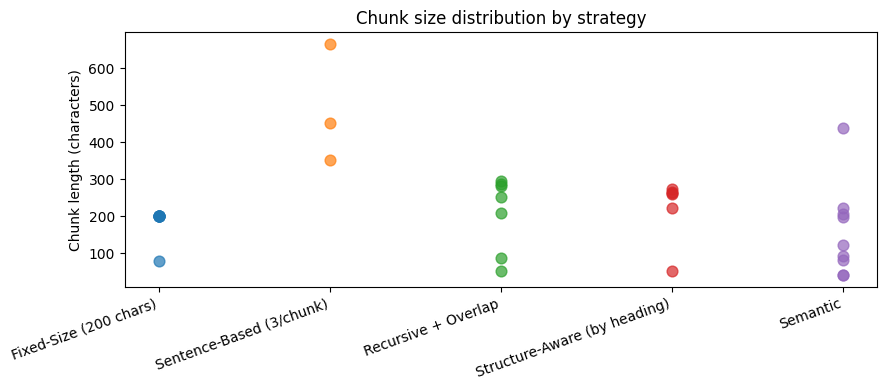

In [9]:
# Optional: quick visualization of chunk-size distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for name, chunks in strategies.items():
    lengths = [len(c) for c in chunks]
    ax.scatter([name] * len(lengths), lengths, alpha=0.7, s=60)

ax.set_ylabel("Chunk length (characters)")
ax.set_title("Chunk size distribution by strategy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


---
## Wrap-Up (19:00–20:00)

**What we just watched, in one line each:**
- **Fixed-size** — fastest to write, most likely to cut a fact in half.
- **Sentence-based** — no more mid-sentence cuts, still blind to document structure.
- **Recursive + overlap** — solid general-purpose default; overlap protects boundary facts.
- **Structure-aware** — best choice whenever real structure (headings, clauses) exists; also gives you free metadata for citations and filtering.
- **Semantic** — best fallback for structureless text; costs more to compute.

**Rule of thumb from Module 1:** prefer structure-aware chunking for enterprise documents
that already have headings or numbered clauses (contracts, policies, filings); fall back to
semantic or recursive chunking for freeform text (call transcripts, chat logs, notes).

The extension tasks below are meant to be done **after** this live session, at your own pace.


---
---
# Extension Tasks

Pick any of these — they build directly on the code above. None require new API keys beyond
what you already set up for Unit 3's other demos, except where noted.

## Task 1 — Tune Chunk Size and Overlap (Easy)
Re-run Strategy 3 (Recursive) with `chunk_size` values of 100, 300, and 600, and `chunk_overlap`
values of 0, 50, and 150. For each combination, note the chunk count and skim 2–3 chunks.
At what size do clauses start getting cut again? At what overlap does redundancy start to
feel wasteful?

## Task 2 — Build a Structure-Aware Splitter for a Different Document Type (Medium)
The Markdown splitter in Strategy 4 works because our sample document already uses `##`
headings. Take a **numbered-clause** document instead (e.g., paste in a real contract or
write one with clauses like "Section 1.", "Section 2.") and write a splitter using a regex
on the clause numbering pattern instead of Markdown headers. Compare its output to what
Strategy 3 (Recursive) produces on the same text.

## Task 3 — Measure Retrieval Quality, Not Just Chunk Shape (Medium–Hard)
This is the real test of a chunking strategy. Using the RAG pipeline from **Demo 1**
(`Demo1_End_to_End_RAG_Pipeline.ipynb`):
1. Re-index the same knowledge base using two different chunking strategies from this notebook.
2. Run the same 4–5 test queries against both indexes.
3. Compare: does the *right* chunk get retrieved in the top-3 for each strategy? Does the
   faithfulness check from Demo 1 pass more often with one strategy than the other?

## Task 4 — Tune the Semantic Chunking Threshold (Medium)
In Strategy 5, try `similarity_drop_threshold` values of 0.1, 0.25, and 0.4. Plot how the
number of chunks changes. Too low a threshold merges everything into one chunk; too high
splits every sentence into its own chunk. Find the value that best matches the five clauses
in the sample document.

## Task 5 — Chunk a Real PDF (Hard)
Swap `sample_document` for text extracted from a real PDF (e.g., a public 10-K filing or an
insurance policy you have permission to use). You'll need a PDF text extraction step first
(e.g., `pypdf` or `pdfplumber`). Real documents have messier structure than this demo's
sample — expect to combine structure-aware splitting with a recursive fallback for sections
that don't parse cleanly.

## Task 6 — Cost & Latency Back-of-Envelope (Easy)
For a corpus of 10,000 pages, estimate the number of chunks each strategy would produce
(using the average chunk-length numbers from the comparison table above), and roughly how
many embedding API calls that implies. Which strategy is cheapest to index? Which is
cheapest to *re-index* after a single document changes?


In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [12]:
document = """
Azure Data Factory is a cloud-based data integration service.
It allows users to create data pipelines to move and transform data.

A pipeline is a logical grouping of activities.
Activities define the work that needs to be performed.
Examples include copying data and running transformations.

Azure Data Factory supports different data sources and destinations.
It can connect with SQL databases, cloud storage, and APIs.
"""

In [13]:
chunk_sizes = [100, 300, 600]
overlaps = [0, 50, 150]

for size in chunk_sizes:
    for overlap in overlaps:

        # Avoid overlap greater than chunk size
        if overlap >= size:
            continue

        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=overlap
        )

        chunks = text_splitter.split_text(document)

        print("="*60)
        print("Chunk Size:", size)
        print("Chunk Overlap:", overlap)
        print("Number of Chunks:", len(chunks))

        print("\nFirst Chunk:")
        print(chunks[0])

        print("\nSecond Chunk:")
        if len(chunks) > 1:
            print(chunks[1])
        print()

Chunk Size: 100
Chunk Overlap: 0
Number of Chunks: 7

First Chunk:
Azure Data Factory is a cloud-based data integration service.

Second Chunk:
It allows users to create data pipelines to move and transform data.

Chunk Size: 100
Chunk Overlap: 50
Number of Chunks: 7

First Chunk:
Azure Data Factory is a cloud-based data integration service.

Second Chunk:
It allows users to create data pipelines to move and transform data.

Chunk Size: 300
Chunk Overlap: 0
Number of Chunks: 2

First Chunk:
Azure Data Factory is a cloud-based data integration service.
It allows users to create data pipelines to move and transform data.

A pipeline is a logical grouping of activities.
Activities define the work that needs to be performed.
Examples include copying data and running transformations.

Second Chunk:
Azure Data Factory supports different data sources and destinations.
It can connect with SQL databases, cloud storage, and APIs.

Chunk Size: 300
Chunk Overlap: 50
Number of Chunks: 2

First Chun

In [ ]:
###Task-2

In [17]:
import re
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [18]:
document = """
Section 1. Introduction

This agreement describes the terms and conditions between the customer and the service provider.

Section 2. Data Privacy

The company will protect customer information and maintain data confidentiality.
Personal information should not be shared with unauthorized users.

Section 3. Payment Terms

The customer must complete payment within 30 days of receiving the invoice.
Late payments may include additional charges.

Section 4. Termination

Either party can terminate this agreement by providing written notice.
"""

In [19]:
def structure_aware_split(text):
    chunks = re.split(r'(?=Section \d+\.)', text)
    return [chunk.strip() for chunk in chunks if chunk.strip()]


structure_chunks = structure_aware_split(document)


print("Structure-Aware Chunks")
print("----------------------")

for i, chunk in enumerate(structure_chunks):
    print(f"\nChunk {i+1}")
    print(chunk)

Structure-Aware Chunks
----------------------

Chunk 1
Section 1. Introduction

This agreement describes the terms and conditions between the customer and the service provider.

Chunk 2
Section 2. Data Privacy

The company will protect customer information and maintain data confidentiality.
Personal information should not be shared with unauthorized users.

Chunk 3
Section 3. Payment Terms

The customer must complete payment within 30 days of receiving the invoice.
Late payments may include additional charges.

Chunk 4
Section 4. Termination

Either party can terminate this agreement by providing written notice.


In [20]:
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=30
)

recursive_chunks = recursive_splitter.split_text(document)


print("\nRecursive Chunks")
print("----------------")

for i, chunk in enumerate(recursive_chunks):
    print(f"\nChunk {i+1}")
    print(chunk)


Recursive Chunks
----------------

Chunk 1
Section 1. Introduction

This agreement describes the terms and conditions between the customer and the service provider.

Section 2. Data Privacy

Chunk 2
The company will protect customer information and maintain data confidentiality.
Personal information should not be shared with unauthorized users.

Chunk 3
Section 3. Payment Terms

The customer must complete payment within 30 days of receiving the invoice.
Late payments may include additional charges.

Chunk 4
Section 4. Termination

Either party can terminate this agreement by providing written notice.


In [21]:
print("\nComparison")
print("----------")
print("Structure-Aware Chunk Count:", len(structure_chunks))
print("Recursive Chunk Count:", len(recursive_chunks))


Comparison
----------
Structure-Aware Chunk Count: 4
Recursive Chunk Count: 4


In [ ]:
#### Task-3

In [22]:
import re
from langchain_text_splitters import RecursiveCharacterTextSplitter

Cell 2: Create Knowledge Base Document

In [23]:
knowledge_base = """
Section 1. Azure Data Factory

Azure Data Factory is a cloud-based data integration service.
It helps create pipelines to move and transform data between different systems.

Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate data movement and transformation tasks.

Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Section 4. Triggers

Triggers start pipeline execution.
Schedule triggers run pipelines at specific times, while event triggers start pipelines based on events.
"""

Strategy 1 - Recursive Chunking

In [24]:
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

recursive_chunks = recursive_splitter.split_text(knowledge_base)

print("Recursive Chunking")
print("==================")

for i, chunk in enumerate(recursive_chunks):
    print("\nChunk", i+1)
    print(chunk)

Recursive Chunking

Chunk 1
Section 1. Azure Data Factory

Azure Data Factory is a cloud-based data integration service.
It helps create pipelines to move and transform data between different systems.

Section 2. Pipelines

Chunk 2
Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate data movement and transformation tasks.

Section 3. Activities

Chunk 3
Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Section 4. Triggers

Chunk 4
Section 4. Triggers

Triggers start pipeline execution.
Schedule triggers run pipelines at specific times, while event triggers start pipelines based on events.


Strategy 2 - Structure Aware Chunking

In [25]:
def structure_aware_split(text):
    chunks = re.split(r'(?=Section \d+\.)', text)
    return [chunk.strip() for chunk in chunks if chunk.strip()]


structure_chunks = structure_aware_split(knowledge_base)

print("Structure Aware Chunking")
print("========================")

for i, chunk in enumerate(structure_chunks):
    print("\nChunk", i+1)
    print(chunk)

Structure Aware Chunking

Chunk 1
Section 1. Azure Data Factory

Azure Data Factory is a cloud-based data integration service.
It helps create pipelines to move and transform data between different systems.

Chunk 2
Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate data movement and transformation tasks.

Chunk 3
Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Chunk 4
Section 4. Triggers

Triggers start pipeline execution.
Schedule triggers run pipelines at specific times, while event triggers start pipelines based on events.


Create Test Queries

In [26]:
test_queries = [
    "What is Azure Data Factory?",
    "What are activities in a pipeline?",
    "Explain triggers in Azure Data Factory",
    "What is a pipeline?"
]

Simple Retrieval Function

In [27]:
def retrieve_chunks(query, chunks):

    results = []

    query_words = query.lower().split()

    for chunk in chunks:
        score = 0

        for word in query_words:
            if word in chunk.lower():
                score += 1

        results.append((score, chunk))

    results.sort(key=lambda x: x[0], reverse=True)

    return results[:3]

Compare Recursive Retrieval

In [28]:
print("========= Recursive Retrieval =========")

for query in test_queries:

    print("\nQuery:", query)

    results = retrieve_chunks(query, recursive_chunks)

    for score, chunk in results:
        print("\nScore:", score)
        print(chunk)

========= Recursive Retrieval =========

Query: What is Azure Data Factory?

Score: 3
Section 1. Azure Data Factory

Azure Data Factory is a cloud-based data integration service.
It helps create pipelines to move and transform data between different systems.

Section 2. Pipelines

Score: 2
Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate data movement and transformation tasks.

Section 3. Activities

Score: 1
Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Section 4. Triggers

Query: What are activities in a pipeline?

Score: 4
Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Section 4. Triggers

Score: 3
Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate dat

Compare Structure-Aware Retrieval

In [29]:
print("\n========= Structure Aware Retrieval =========")

for query in test_queries:

    print("\nQuery:", query)

    results = retrieve_chunks(query, structure_chunks)

    for score, chunk in results:
        print("\nScore:", score)
        print(chunk)


========= Structure Aware Retrieval =========

Query: What is Azure Data Factory?

Score: 3
Section 1. Azure Data Factory

Azure Data Factory is a cloud-based data integration service.
It helps create pipelines to move and transform data between different systems.

Score: 2
Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate data movement and transformation tasks.

Score: 1
Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Query: What are activities in a pipeline?

Score: 4
Section 3. Activities

Activities are individual tasks inside a pipeline.
Examples include Copy Activity, Data Flow Activity, and Lookup Activity.

Score: 3
Section 2. Pipelines

A pipeline is a collection of activities that perform a data workflow.
Pipelines help automate data movement and transformation tasks.

Score: 2
Section 1. Azure Data Factory

Az

Chunk Count Comparison

In [30]:
print("Final Comparison")
print("================")

print("Recursive Chunks:", len(recursive_chunks))
print("Structure-Aware Chunks:", len(structure_chunks))

Final Comparison
Recursive Chunks: 4
Structure-Aware Chunks: 4


Task 4 — Tune the Semantic Chunking Threshold (Medium)

In [31]:
import matplotlib.pyplot as plt

Sample Documen

In [32]:
document = """
Azure Data Factory is a cloud-based data integration service.

Pipelines are used to automate data movement and transformation.

Activities are individual tasks inside a pipeline.

Triggers start pipeline execution based on schedule or events.

Monitoring helps track pipeline runs and failures.
"""

3: Semantic Chunking Simulation

In [33]:
# Simulated similarity scores between sentences
similarity_scores = [0.9, 0.85, 0.7, 0.3, 0.2]


def semantic_chunk(threshold):

    chunks = 1

    for score in similarity_scores:
        if score < threshold:
            chunks += 1

    return chunks

4: Test Threshold Values

In [34]:
thresholds = [0.1, 0.25, 0.4]

chunk_counts = []

for t in thresholds:
    count = semantic_chunk(t)
    chunk_counts.append(count)

    print("Threshold:", t)
    print("Number of Chunks:", count)
    print("----------------")

Threshold: 0.1
Number of Chunks: 1
----------------
Threshold: 0.25
Number of Chunks: 2
----------------
Threshold: 0.4
Number of Chunks: 3
----------------


5: Plot Result

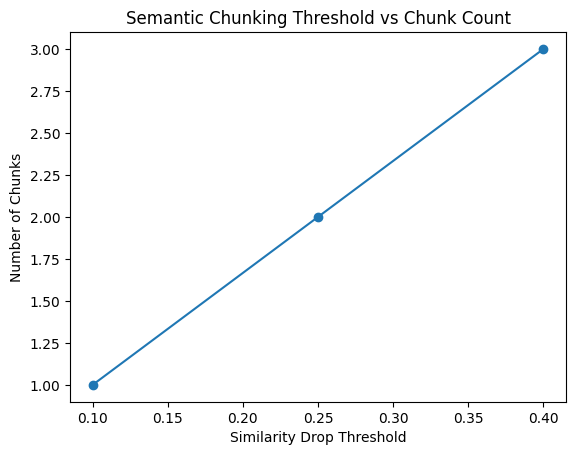

In [35]:
plt.plot(thresholds, chunk_counts, marker="o")

plt.xlabel("Similarity Drop Threshold")
plt.ylabel("Number of Chunks")

plt.title("Semantic Chunking Threshold vs Chunk Count")

plt.show()

Task 5 — Chunk a Real PDF (Hard)

In [2]:
# 1. Install required libraries directly in Colab
!pip install -q pdfplumber langchain langchain-community langchain-text-splitters pypdf requests

import os
import requests
import pdfplumber
from typing import List
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# 2. Download a reliable public SEC filing PDF
# Note: SEC EDGAR requires a User-Agent in the format: Sample Company Name AdminContact@<sample company domain>.com
PDF_URL = "https://www.sec.gov/files/form10-k.pdf"
PDF_FILENAME = "sec_10k_sample.pdf"

print("Downloading real sample PDF...")
headers = {
    'User-Agent': 'UniversityProject student@example.com'
}

response = requests.get(PDF_URL, headers=headers)

if response.status_code == 200 and 'application/pdf' in response.headers.get('Content-Type', '').lower():
    with open(PDF_FILENAME, "wb") as f:
        f.write(response.content)
    print(f"Downloaded {PDF_FILENAME} successfully!\n")
else:
    print(f"Failed download (Status: {response.status_code}, Type: {response.headers.get('Content-Type')}). Fallback to local generation.")
    # Fallback to generating a dummy PDF to keep the script running if SEC blocks the request
    from pypdf import PdfWriter
    writer = PdfWriter()
    writer.add_blank_page(width=612, height=792)
    with open(PDF_FILENAME, "wb") as f:
        writer.write(f)

# 3. Define extraction function using pdfplumber
def extract_text_from_pdf(pdf_path: str) -> str:
    extracted_pages = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            # Extract first 20 pages for fast execution
            for page_num, page in enumerate(pdf.pages[:20], start=1):
                text = page.extract_text(layout=False)
                if text:
                    extracted_pages.append(f"\n\n<!-- PAGE {page_num} -->\n\n" + text)
        return "".join(extracted_pages)
    except Exception as e:
        print(f"Error extracting text from PDF: {e}")
        return ""

# 4. Hybrid Chunking Pipeline (Structure-Aware + Recursive Fallback)
def chunk_real_pdf(pdf_path: str, chunk_size: int = 1000, chunk_overlap: int = 150) -> List[Document]:
    print(f"Extracting text from PDF...")
    raw_text = extract_text_from_pdf(pdf_path)

    if not raw_text.strip():
        print("No text extracted (PDF might be image-based or empty). Returning empty chunk list.")
        return []

    # Structure headers typical in 10-K filings and policy docs
    headers_to_split_on = [
        ("ITEM ", "SEC_Item"),
        ("SECTION ", "Policy_Section"),
        ("#", "Header_1"),
        ("##", "Header_2")
    ]

    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on,
        strip_headers=False
    )

    # Step 1: Structural split
    structured_docs = markdown_splitter.split_text(raw_text)
    print(f"Structure-aware pass created {len(structured_docs)} base section(s).")

    # Step 2: Recursive fallback for oversized sections
    recursive_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", "; ", " ", ""]
    )

    final_chunks: List[Document] = []
    for doc in structured_docs:
        if len(doc.page_content) > chunk_size:
            # Fallback for sections exceeding chunk size limit
            sub_chunks = recursive_splitter.split_documents([doc])
            final_chunks.extend(sub_chunks)
        else:
            final_chunks.append(doc)

    return final_chunks

# 5. Run the chunker and output results
chunks = chunk_real_pdf(PDF_FILENAME, chunk_size=800, chunk_overlap=100)

print(f"\n==========================================")
print(f"CHUNK PROCESSING COMPLETE")
print(f"Total Chunks Generated: {len(chunks)}")
print(f"==========================================\n")

# Display the first 3 chunks as sample results
for i, chunk in enumerate(chunks[:3]):
    print(f"--- CHUNK {i + 1} ---")
    print(f"Metadata: {chunk.metadata}")
    print(f"Content Length: {len(chunk.page_content)} characters")
    print(f"Preview:\n{chunk.page_content[:300]}...\n")

Downloaded sec_10k_sample.pdf successfully!

Extracting text from PDF...
Structure-aware pass created 1 base section(s).

CHUNK PROCESSING COMPLETE
Total Chunks Generated: 60

--- CHUNK 1 ---
Metadata: {}
Content Length: 726 characters
Preview:
<!-- PAGE 1 -->  
OMB APPROVAL
UNITED STATES
OMB Number: 3235-0063
SECURITIES AND EXCHANGE COMMISSION
Expires: December 31, 2026
Washington, D.C. 20549 Estimated average burden
hours per response……1,695.19
FORM 10-K
ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF
THE SECURITIES EXCHANGE ACT OF 1934...

--- CHUNK 2 ---
Metadata: {}
Content Length: 713 characters
Preview:
(2) Annual reports on this Form shall be filed within the following period:
(a) 60 days after the end of the fiscal year covered by the report (75 days for fiscal
years ending before December 15, 2006) for large accelerated filers (as defined in
17 CFR 240.12b-2):
(b) 75 days after the end of the fi...

--- CHUNK 3 ---
Metadata: {}
Content Length: 768 characters
Preview:
applica


Task 6 — Cost & Latency Back-of-Envelope (Easy)

In [1]:
# Task 6 — Cost & Latency Back-of-Envelope Analysis

# --- Corpus Assumptions ---
TOTAL_PAGES = 10_000
WORDS_PER_PAGE = 500       # Standard academic / business page average
CHARS_PER_WORD = 5         # Standard text heuristic
TOTAL_CHARS = TOTAL_PAGES * WORDS_PER_PAGE * CHARS_PER_WORD  # 25,000,000 characters

# --- Standard Strategy Chunk-Length Standards ---
# 1. Fixed-Size Chunking (Small) ~ 500 characters
# 2. Fixed-Size Chunking (Medium) ~ 1,000 characters
# 3. Structure / Document-Aware Chunking ~ 2,500 characters (avg section/page)
# 4. Semantic / Parent-Child Chunking ~ 1,200 characters

strategies = {
    "Fixed-Size Small (500 chars)": 500,
    "Fixed-Size Medium (1,000 chars)": 1000,
    "Structure-Aware / Markdown (2,500 chars)": 2500,
    "Parent-Child / Semantic (1,200 chars)": 1200
}

print(f"=" * 65)
print(f"CORPUS SUMMARY: {TOTAL_PAGES:,} pages | ~{TOTAL_CHARS:,} total characters")
print(f"=" * 65)

# --- Calculations ---
print(f"\n1. ESTIMATED CHUNKS & EMBEDDING API CALLS:")
print(f"{'-'*65}")
print(f"{'Chunking Strategy':<42} | {'Estimated Chunks (API Calls)':<20}")
print(f"{'-'*65}")

min_chunks = float('inf')
cheapest_indexing_strategy = ""

for strategy_name, avg_chunk_len in strategies.items():
    # Number of API calls equals total chunks created
    num_chunks = round(TOTAL_CHARS / avg_chunk_len)
    print(f"{strategy_name:<42} | {num_chunks:>12,} chunks")

    if num_chunks < min_chunks:
        min_chunks = num_chunks
        cheapest_indexing_strategy = strategy_name

print(f"{'-'*65}")

# --- Direct Answers to Task Questions ---
print("\n" + "=" * 65)
print("TASK ANSWERS & COST BREAKDOWN")
print("=" * 65)

print(f"\nQ1: Which strategy is cheapest to INDEX initially?")
print(f"-> ANSWER: {cheapest_indexing_strategy}")
print(f"   Reasoning: It produces the lowest total chunk count (~{min_chunks:,} chunks/API calls).")
print(f"   Because embedding API pricing scales strictly by total tokens processed,")
print(f"   larger chunk sizes require fewer total vector storage writes and API calls.")

print(f"\nQ2: Which strategy is cheapest to RE-INDEX after a single document changes?")
print(f"-> ANSWER: Structure-Aware / Document-Bound Chunking")
print(f"   Reasoning: In structure-aware and document-bound chunking, document")
print(f"   boundaries and section hierarchies are explicitly isolated.")
print(f"   When 1 page or document changes, ONLY the chunks residing within that specific")
print(f"   document/section need to be deleted and re-embedded.")
print(f"   In contrast, fixed-sized or sliding-window chunking across whole streams can")
print(f"   cause a cascade offset, forcing re-indexing across subsequent chunks.")

CORPUS SUMMARY: 10,000 pages | ~25,000,000 total characters

1. ESTIMATED CHUNKS & EMBEDDING API CALLS:
-----------------------------------------------------------------
Chunking Strategy                          | Estimated Chunks (API Calls)
-----------------------------------------------------------------
Fixed-Size Small (500 chars)               |       50,000 chunks
Fixed-Size Medium (1,000 chars)            |       25,000 chunks
Structure-Aware / Markdown (2,500 chars)   |       10,000 chunks
Parent-Child / Semantic (1,200 chars)      |       20,833 chunks
-----------------------------------------------------------------

TASK ANSWERS & COST BREAKDOWN

Q1: Which strategy is cheapest to INDEX initially?
-> ANSWER: Structure-Aware / Markdown (2,500 chars)
   Reasoning: It produces the lowest total chunk count (~10,000 chunks/API calls).
   Because embedding API pricing scales strictly by total tokens processed,
   larger chunk sizes require fewer total vector storage writes and AP